In [24]:
%load_ext autoreload
%autoreload 0
%matplotlib inline

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [25]:
import re,sys,os
import pandas as pd
import numpy as np
from tqdm import tqdm
from pathlib import Path
import matplotlib.pyplot as plt
import matplotlib
import seaborn as sns

# Set font to Arial
matplotlib.rcParams['font.family'] = 'Arial'

# Optional: Set PDF to embed fonts (for Illustrator editing)
matplotlib.rcParams['pdf.fonttype'] = 42  # TrueType fonts for better editing


In [26]:
from omicsone_streamlit.utils.diff import compare_two_groups
from omicsone_streamlit.plots.volcano import plot_volcano

In [27]:
DATA_DIR = Path(r"E:\lab\cptac-prostate\runs\20260401_quality_control")
OUTPUT_DIR = Path(r"E:\lab\cptac-prostate\runs\20260401_mspycloud_cptac_protein_tmt_pca")
OUTPUT_DIR.mkdir(exist_ok=True)
print(DATA_DIR.exists(), OUTPUT_DIR.exists())
meta_path = DATA_DIR / "20_MetaData_03_12_2026_renamed.csv"

True True


In [28]:
meta = pd.read_csv(meta_path)
meta_normal = meta[meta["Tissuetype"] == "normal"]
meta_tumor = meta[meta["Tissuetype"] == "tumor"]
purity_map = dict(zip(meta["SampleID"], meta["FirstCategory"]))
stage_map = dict(zip(meta["SampleID"], meta["stage"]))
gleason_map = dict(zip(meta["SampleID"], meta["Grade_Group"]))
# tumors_included = meta_tumor['SampleID'].tolist()
normals = meta_normal['SampleID'].tolist()

In [29]:
meta

,case_id,common_ID,Tissuetype,include_or_excludetumor,FirstCategory,AdditionalSegments,SecondCategory,ThirdCategory,all_drivers,Main_Groups,...,Normal_Pam50,Basal,Her2,LumA,LumB,Normal,agg_rank_raw,agg_rank_scaled,risk_group,SampleID
0,C3L-07287,C3L.07287.T,tumor,Include,Sufficient Purity,ETS,ETS,NaN,ERG,ERG,...,0.000000,0.0,0.0,1.0,0.0,0.0,55.333000,0.409000,IR,C3L-07287_T
1,C3L-11156,C3L.11156.T,tumor,Include,Sufficient Purity,ETS,ETS,NaN,ERG,ERG,...,0.498000,0.0,0.0,1.0,0.0,0.0,44.167000,0.325000,LR,C3L-11156_T
2,C3L-09494,C3L.09494.T,tumor,Include,Sufficient Purity,ETS,ETS,NaN,ERG,ERG,...,0.000000,0.0,1.0,0.0,0.0,0.0,123.167000,0.919000,HR,C3L-09494_T
3,CHTN-49141,CHTN.49141.T,tumor,Include,Sufficient Purity,ETS,ETS,NaN,ERG,ERG,...,0.000000,0.0,1.0,0.0,0.0,0.0,103.833000,0.773000,HR,CHTN-49141_T
4,C3L-11095,C3L.11095.T,tumor,Include,Sufficient Purity,ETS,ETS,NaN,ERG,ERG,...,0.369000,0.0,0.0,1.0,0.0,0.0,44.667000,0.328000,LR,C3L-11095_T
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
178,C3L-07872,C3L.07872.T,tumor,Include,Low Purity,NaN,NaN,NaN,ERG,ERG,...,0.460832,1.0,0.0,0.0,0.0,0.0,73.666667,0.546366,IR,C3L-07872_T
179,C3L-08642,C3L.08642.T,tumor,Include,Low Purity,NaN,NaN,NaN,ERG,ERG,...,0.334840,0.0,0.0,1.0,0.0,0.0,46.166667,0.339599,LR,C3L-08642_T
180,C3L-10399,C3L.10399.T,tumor,Include,Low Purity,NaN,NaN,NaN,ERG,ERG,...,0.445334,0.0,0.0,1.0,0.0,0.0,60.000000,0.443609,IR,C3L-10399_T
181,C3L-05301,C3L.05301.T,tumor,Include,Low Purity,NaN,NaN,NaN,ETV1,ETV1,...,0.457908,0.0,0.0,1.0,0.0,0.0,45.333333,0.333333,LR,C3L-05301_T


In [30]:
tumors_included = meta[(meta['Tissuetype'] == 'tumor') 
                       & (meta['FirstCategory'] == "Sufficient Purity")
                       & (meta["Grade_Group"].isin(["GG3"]))]['SampleID'].tolist()
print(len(tumors_included), len(normals))

31 33


In [31]:
# data
files = [i for i in DATA_DIR.iterdir() if i.is_file()]
files = [i for i in files if re.search(r"mspycloud_Global_DDA_TMT_log2ratio",i.stem, re.IGNORECASE) \
    and not re.search(r"tumor_purity_corrected",i.stem, re.IGNORECASE)]
data_path = files[0]
protein_header_cols = ["Protein.Group.Accessions"]
data = pd.read_csv(data_path,sep="\t").set_index(protein_header_cols)
data_nomiss = data.dropna()

In [32]:
data

,Reference Sample 1,C3L-05292_T,C3L-09383_T,CHTN-43798_T,C3L-06261_N,C3L-08811_T,C3L-06506_N,C3L-07804_T,C3L-06595_T,C3L-06742_T,...,CHTN-44966_T,C3L-11192_N,C3L-08805_T,C3L-09760_T,C3L-08444_T,C3L-08291_T,C3L-10583_T,C3L-07877_T,C3L-08377_T,C3L-08736_T
Protein.Group.Accessions,,,,,,,,,,,,,,,,,,,,,
ENSP00000000233|ENST00000000233|ENSG00000004059|ARF5 ADP ribosylation factor 5,0.0,0.077017,-0.187993,-0.137950,-0.255903,0.235679,-0.122157,0.049047,-0.150472,0.090129,...,0.177651,-0.184215,-0.495843,0.065143,0.050001,0.262834,-0.221609,0.084544,-0.024535,0.266896
"ENSP00000000412|ENST00000000412|ENSG00000003056|M6PR mannose-6-phosphate receptor, cation dependent",0.0,0.122390,0.036646,0.179340,0.038353,0.361856,0.023644,-0.226568,-0.218785,-0.029380,...,-0.210005,-0.509339,0.323025,0.112554,-0.003882,-0.364879,-0.290935,0.175473,0.113948,0.242116
ENSP00000001008|ENST00000001008|ENSG00000004478|FKBP4 FKBP prolyl isomerase 4,0.0,-0.158774,-0.185559,-0.186552,-0.403156,0.400005,-0.286488,-0.581658,-0.184171,0.472634,...,-0.235445,-0.561989,-0.306163,0.162003,0.084839,0.157711,-0.421211,-0.058981,-0.186794,0.220484
ENSP00000002125|ENST00000002125|ENSG00000003509|NDUFAF7 NADH:ubiquinone oxidoreductase complex assembly factor 7,0.0,-0.007247,0.085730,-0.037076,-0.063520,0.155436,-0.019618,-0.203342,0.050553,-0.125149,...,-0.261797,0.020816,0.195666,0.066049,0.017390,-0.083763,0.028189,-0.052304,-0.023878,0.302151
ENSP00000002165|ENST00000002165|ENSG00000001036|FUCA2 alpha-L-fucosidase 2,0.0,0.075815,0.295018,0.097095,-0.751552,0.072959,-0.744420,-1.052637,-0.236417,0.532446,...,0.024258,-0.138183,-0.132877,0.102094,-0.293056,0.623585,-0.611337,-0.503879,0.224542,0.707597
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
ENSP00000307014|ENST00000305748|ENSG00000186049|KRT73 keratin 73,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.705524,1.032750,-0.274949,-0.305077,0.167676,-0.272981,0.215760,0.833478,0.328482,-0.000854
"ENSP00000312070|ENST00000308177|ENSG00000240184|PCDHGC3 protocadherin gamma subfamily C, 3",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.016368,0.176268,0.339498,0.119363,0.172382,-0.108952,0.503057,0.065289,0.034634,-0.416416
ENSP00000452370|ENST00000557607|ENSG00000100722|ZC3H14 zinc finger CCCH-type containing 14,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.492035,0.539346,-0.074879,-0.652922,-0.225059,0.028898,0.282637,-0.544384,0.020144,0.257734


In [33]:
total_genes = sorted(set([i.split("|")[-1].split(" ")[0] for i in data.index]))
print(len(total_genes))

9196


In [34]:
print(len(tumors_included), len(normals))

31 33


In [35]:
fc = 1.5
diff = compare_two_groups(data, tumors_included, normals, 
                                method="Wilcoxon(Unpaired)",
                                max_miss_ratio_global=0.5, 
                                max_miss_ratio_group=0.5,
                                fdr_cutoff=0.01, 
                                log2fc_cutoff=np.log2(fc))

9688it [00:07, 1274.66it/s]


In [36]:
diff

,Log2FC(median),Log2FC(mean),Wilcoxon(Unpaired)(Stats),Wilcoxon(Unpaired)(P-value),FDR,-Log10(FDR),Significance
Feature,,,,,,,
ENSP00000000233|ENST00000000233|ENSG00000004059|ARF5 ADP ribosylation factor 5,0.243904,0.286196,932.0,1.679297e-08,2.226893e-07,6.652301,U
"ENSP00000000412|ENST00000000412|ENSG00000003056|M6PR mannose-6-phosphate receptor, cation dependent",0.048883,0.152333,640.0,8.552055e-02,1.268254e-01,0.896794,None
ENSP00000001008|ENST00000001008|ENSG00000004478|FKBP4 FKBP prolyl isomerase 4,0.462877,0.481582,981.0,2.968549e-10,1.570071e-08,7.804081,U
ENSP00000002125|ENST00000002125|ENSG00000003509|NDUFAF7 NADH:ubiquinone oxidoreductase complex assembly factor 7,0.117837,0.053658,610.0,1.880049e-01,2.502175e-01,0.601682,None
ENSP00000002165|ENST00000002165|ENSG00000001036|FUCA2 alpha-L-fucosidase 2,0.377054,0.343885,752.0,1.263730e-03,3.171456e-03,2.498741,U
...,...,...,...,...,...,...,...
ENSP00000337759|ENST00000337523|ENSG00000204348|DXO decapping exoribonuclease,0.323420,0.253265,322.0,2.788993e-02,4.830454e-02,1.316012,None
ENSP00000362376|ENST00000373279|ENSG00000171224|FAM241B family with sequence similarity 241 member B,-0.182095,-0.118246,136.0,2.034676e-01,2.682219e-01,0.571506,None
ENSP00000363377|ENST00000374259|ENSG00000184481|FOXO4 forkhead box O4,-0.410492,-0.406654,121.0,7.803303e-03,1.578921e-02,1.801640,None


In [37]:
diff['Significance'] = diff['Significance'].apply(lambda x: 'NS' if pd.isna(x) else x)

In [38]:
xmin = diff['Log2FC(median)'].min()
xmax = diff['Log2FC(median)'].max()
print(xmin, xmax)
xlimit = np.max([abs(np.floor(xmin)), np.ceil(xmax)])
print(xlimit)

-1.6592697594503445 1.4474266129903997
2.0


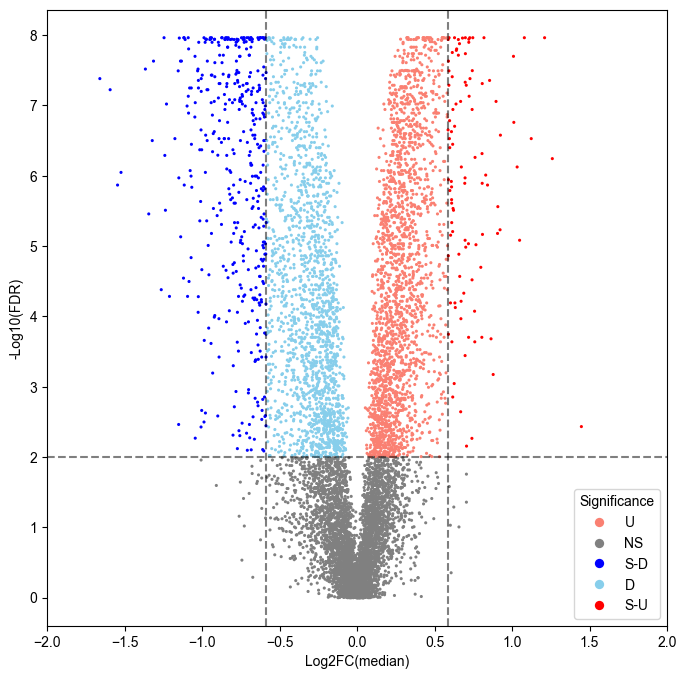

In [39]:
fig = plot_volcano(diff,
                   log2fc_threshold=np.log2(fc),
                   xlim = (-1 * xlimit, xlimit))

In [40]:
diff[diff['Significance'] == 'S-U']

,Log2FC(median),Log2FC(mean),Wilcoxon(Unpaired)(Stats),Wilcoxon(Unpaired)(P-value),FDR,-Log10(FDR),Significance
Feature,,,,,,,
ENSP00000009530|ENST00000009530|ENSG00000019582|CD74 CD74 molecule,0.617471,0.598201,771.0,5.026651e-04,1.399691e-03,2.853968,S-U
ENSP00000219611|ENST00000219611|ENSG00000103326|CAPN15 calpain 15,0.701367,0.753781,867.0,1.851713e-06,1.035014e-05,4.985054,S-U
ENSP00000222271|ENST00000222271|ENSG00000105664|COMP cartilage oligomeric matrix protein;ENSP00000439156|ENST00000542601|ENSG00000105664|COMP cartilage oligomeric matrix protein,0.864507,0.950064,811.0,5.902359e-05,2.081179e-04,3.681691,S-U
ENSP00000226796|ENST00000226796|ENSG00000109534|GAR1 GAR1 ribonucleoprotein,0.614096,0.712082,963.0,1.373067e-09,3.901729e-08,7.408743,S-U
ENSP00000244020|ENST00000244020|ENSG00000124193|SRSF6 serine and arginine rich splicing factor 6;ENSP00000499517|ENST00000668808|ENSG00000124193|SRSF6 serine and arginine rich splicing factor 6,0.609237,0.592328,931.0,1.815449e-08,2.356222e-07,6.627784,S-U
...,...,...,...,...,...,...,...
ENSP00000507697|ENST00000683429|ENSG00000131844|MCCC2 methylcrotonyl-CoA carboxylase subunit 2,0.741156,0.683885,576.0,2.307207e-03,5.417230e-03,2.266223,S-U
ENSP00000508597|ENST00000686568|ENSG00000119335|SET SET nuclear proto-oncogene,0.742541,0.706782,816.0,6.999018e-09,1.140354e-07,6.942960,S-U
ENSP00000509063|ENST00000686683|ENSG00000189221|MAOA monoamine oxidase A,0.697275,0.777001,871.0,1.416253e-06,8.253959e-06,5.083338,S-U


In [41]:
diff2 = diff.copy()
diff2.index = [ i.split("|")[-1].split(" ")[0] for i in diff.index ]

In [42]:
from omicsone_streamlit.utils.pathway import omicsone_enrichr

In [43]:
su_genes = diff2[diff2['Significance'] == 'S-U'].index.tolist()
sd_genes = diff2[diff2['Significance'] == 'S-D'].index.tolist()
u_genes = diff2[diff2['Significance'] == 'U'].index.tolist()
d_genes = diff2[diff2['Significance'] == 'D'].index.tolist()
print(len(su_genes), len(sd_genes), len(u_genes), len(d_genes))

102 409 2057 1696


In [44]:
out_dir = OUTPUT_DIR / "genes_protein_GG3_vs_normal"
out_dir.mkdir(exist_ok=True)
with open(out_dir / "S-U_genes.txt", "w") as f:
    f.write("\n".join(su_genes))
    f.close()
with open(out_dir / "S-D_genes.txt", "w") as f:
    f.write("\n".join(sd_genes))
    f.close()
with open(out_dir / "U_genes.txt", "w") as f:
    f.write("\n".join(u_genes))
    f.close()
with open(out_dir / "D_genes.txt", "w") as f:
    f.write("\n".join(d_genes))
    f.close()

In [45]:
import gseapy
names = gseapy.get_library_name()
[i for i in names if "Hallmark" in i]

['MSigDB_Hallmark_2020']

In [46]:
out_dir = OUTPUT_DIR / "enrichr_protein_GG3_vs_normal_hallmark"
out_dir.mkdir(exist_ok=True)
omicsone_enrichr(su_genes, total_genes=total_genes, 
                 gene_sets="MSigDB_Hallmark_2020", 
                 fdr = 0.05,
                 outdir=out_dir)

,Gene_set,Term,Overlap,P-value,Adjusted P-value,Old P-value,Old Adjusted P-value,Odds Ratio,Combined Score,Genes,-Log10(Adj.P)
0,MSigDB_Hallmark_2020,Myc Targets V1,7/200,0.000070,0.002240,0,0,7.603462,72.741598,RSL1D1;NPM1;SET;UBE2E1;NHP2;NOLC1;HNRNPA1,2.649704
1,MSigDB_Hallmark_2020,Unfolded Protein Response,5/113,0.000271,0.004336,0,0,9.544271,78.390336,NPM1;DKC1;NHP2;NOLC1;HYOU1,2.362888
2,MSigDB_Hallmark_2020,Fatty Acid Metabolism,5/158,0.001243,0.013261,0,0,6.721814,44.969157,CPT2;MAOA;FASN;ECI2;CRAT,1.877416
3,MSigDB_Hallmark_2020,Xenobiotic Metabolism,5/200,0.003469,0.022202,0,0,5.262821,29.807891,MCCC2;MAOA;ENTPD5;PYCR1;FBP1,1.653604
4,MSigDB_Hallmark_2020,Oxidative Phosphorylation,5/200,0.003469,0.022202,0,0,5.262821,29.807891,ALDH6A1;GRPEL1;COX17;PMPCA;ACADSB,1.653604
